# 23CSE301 Machine Learning - Capstone Project (Review 1)
## Track 1: Full Regression Track Pipeline — California Housing Dataset

**Course**: 23CSE301 Machine Learning  
**Program**: B.Tech. Computer Science and Engineering  
**Academic Year**: 2026-27  
**Dataset**: California Housing Dataset (`housing.csv` — 20,640 records, 10 features)  
**Target Variable**: `median_house_value` (Continuous Monetary Value in USD)  

---

### Notebook Overview & Review 1 Alignment
This notebook implements the complete **Full Regression Track** per the official evaluation rubrics:
1. **Section A (Dataset Audit & EDA)**: Data inspection, summary statistics, skewness check, missing value audit, and 4 detailed visualizations with domain commentary.
2. **Section B (Preprocessing & Feature Engineering)**: Outlier treatment, median imputation, 3 engineered interaction features, One-Hot Encoding, scaling (`StandardScaler`), and 80:20 Train/Test split.
3. **Section C (Model Evaluation & Diagnostics)**: Benchmark of **all 10 mandated regression algorithms**, 5-fold cross-validation, hyperparameter tuning (`GridSearchCV`), residual plots, predicted vs. actual plots, feature importances, and serialization of the best model.


In [1]:
# Essential Libraries Import
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 10 Mandated Regression Algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print("All regression libraries successfully loaded!")


All regression libraries successfully loaded!


## Section A - Dataset Loading & Exploratory Data Analysis (EDA)

### A1: Dataset Audit & Summary Statistics
We load the real California Housing Dataset (`housing.csv`) containing census block group attributes in California.


In [2]:
# Load California Housing Dataset
data_path = '../data/housing.csv'
df_raw = pd.read_csv(data_path)

print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\n--- Data Info & Missing Values ---")
print(df_raw.info())

print("\n--- Missing Value Count per Column ---")
print(df_raw.isnull().sum())

print("\n--- Summary Statistics of Numerical Attributes ---")
display(df_raw.describe().T)


Dataset Shape: 20640 rows, 10 columns

--- Data Info & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB
None

--- Missing Value Count per Column ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population       

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


### A3 Insight Commentary: Dataset Audit
* **Dataset Scale**: The dataset contains 20,640 records across 10 features (9 numerical, 1 categorical).
* **Target Variable (`median_house_value`)**: Values range from $14,999 to $500,001 with a mean of ~$206,855. Note the upper cap at $500,001.
* **Missing Values**: `total_bedrooms` contains 207 missing values (~1.0% of data), which will be imputed using median imputation during Section B.
* **Categorical Variable (`ocean_proximity`)**: Contains 5 categories (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`).


### A2: EDA Visualizations
We examine feature distributions, target distribution, feature correlations, and relationship with ocean proximity.


In [3]:
print(df_raw.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [4]:
# Define regression target
target_col = "median_house_value"

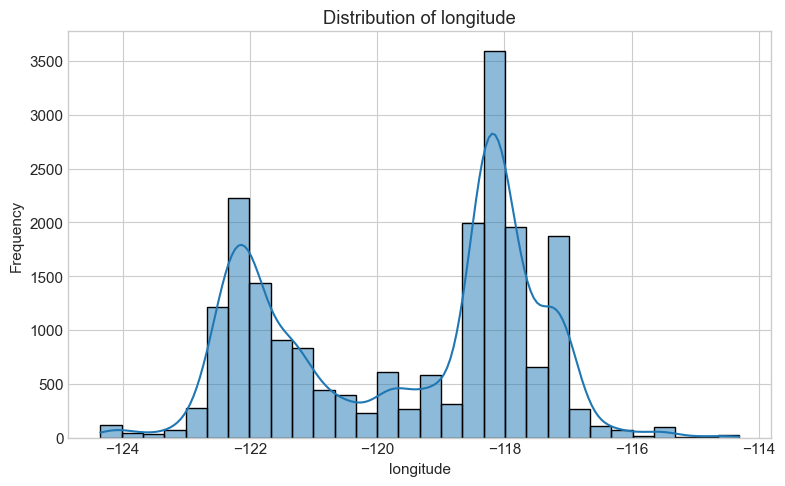

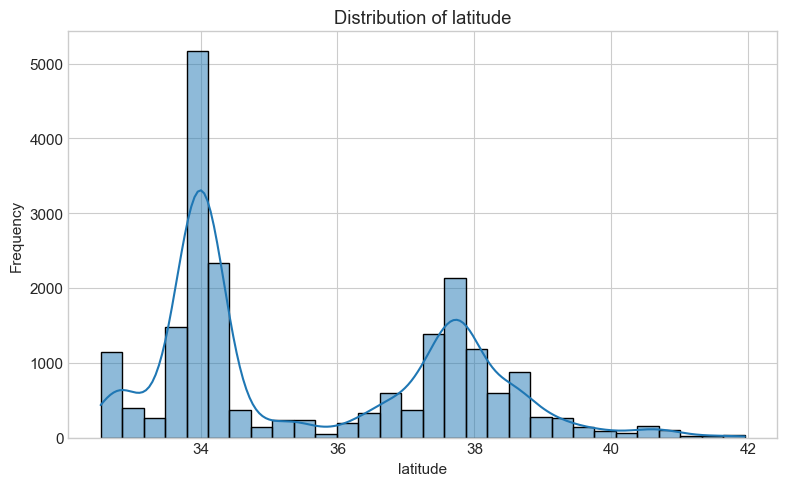

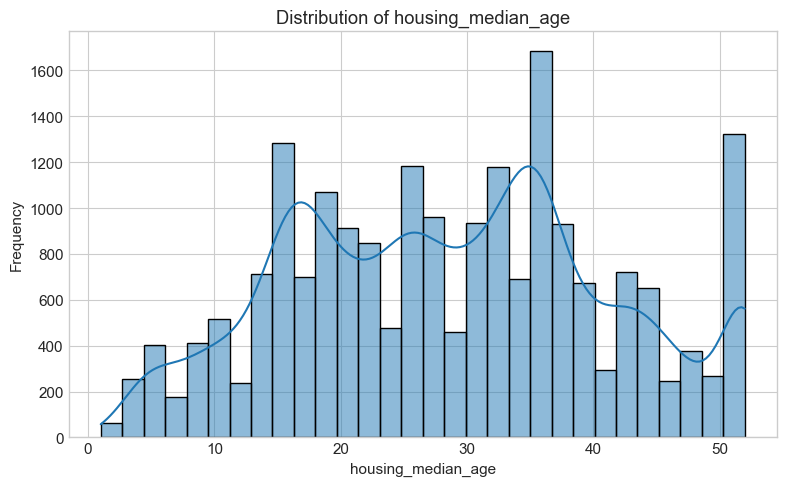

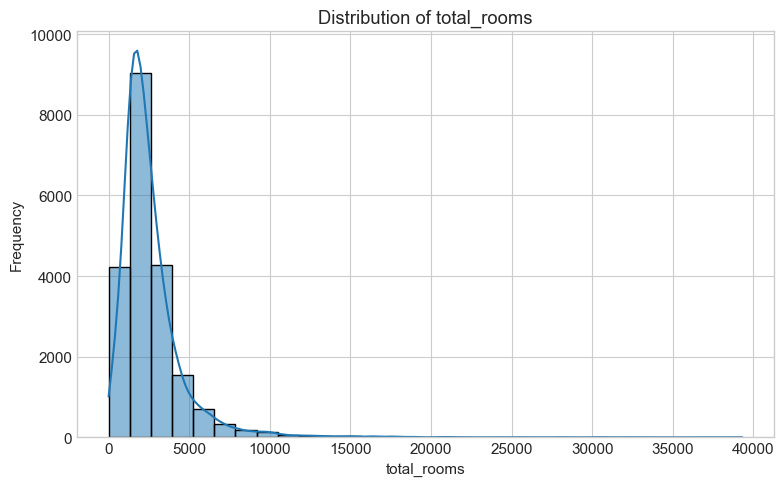

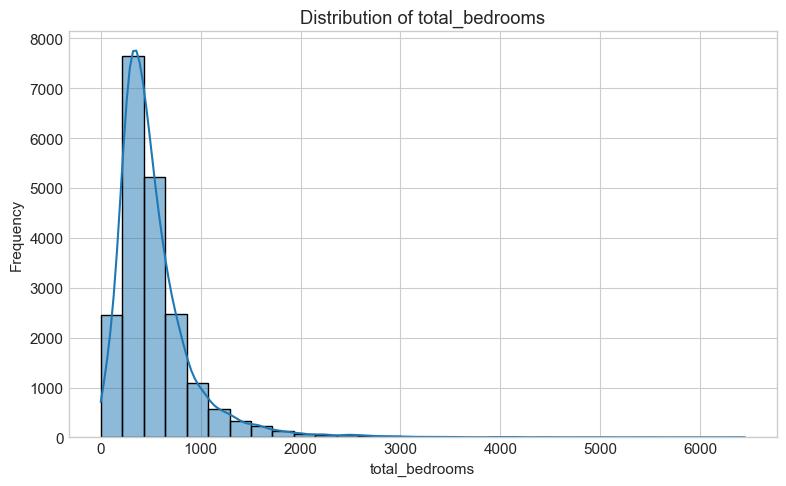

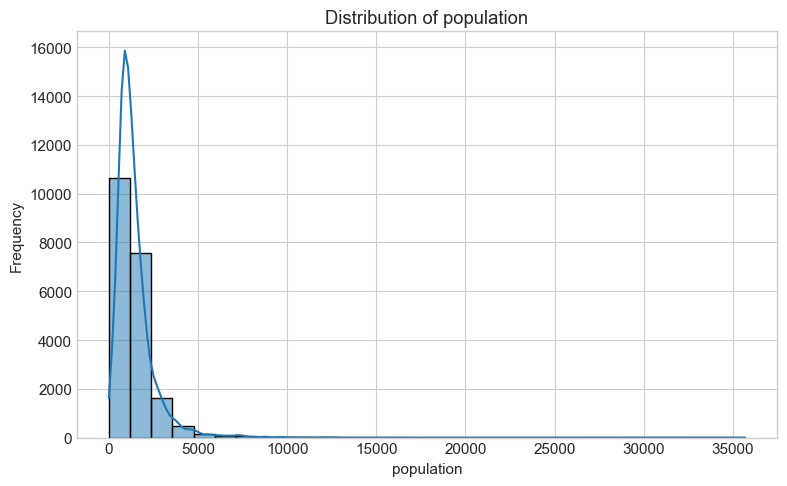

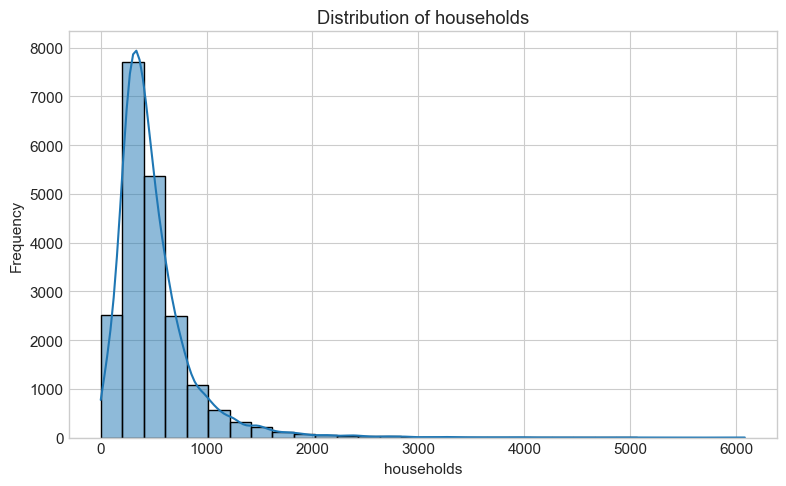

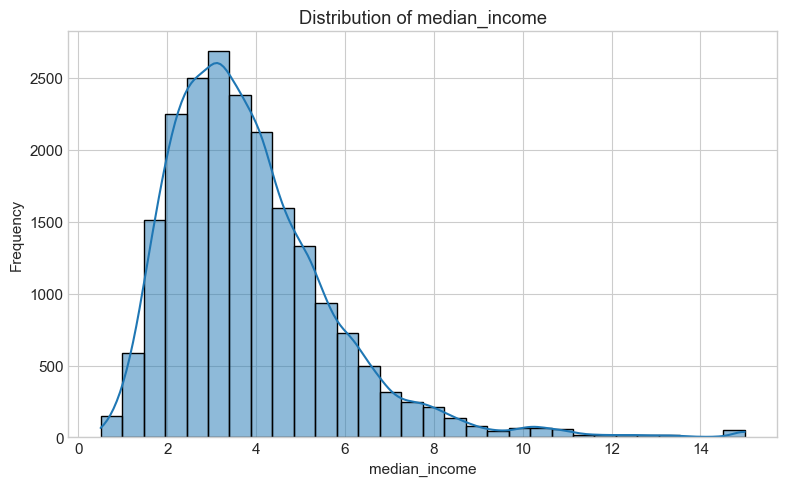

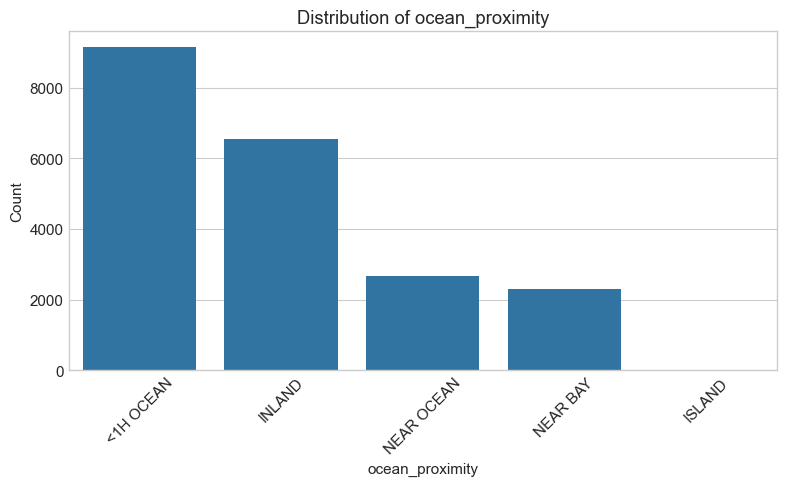

In [5]:
# ============================================================
# REGRESSION — A2: DISTRIBUTION PLOTS FOR EVERY FEATURE
# ============================================================
features = [col for col in df_raw.columns if col != target_col]

for col in features:

    plt.figure(figsize=(8, 5))

    if pd.api.types.is_numeric_dtype(df_raw[col]):
        sns.histplot(df_raw[col].dropna(), kde=True, bins=30)
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {col}")

    else:
        order = df_raw[col].value_counts().head(15).index

        sns.countplot(
            data=df_raw,
            x=col,
            order=order
        )

        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

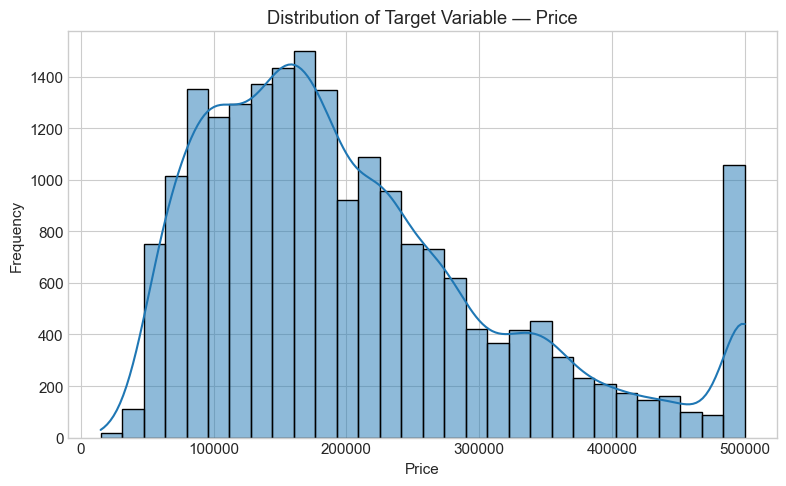

In [6]:
# ============================================================
# REGRESSION — A2: TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(df_raw[target_col].dropna(), kde=True, bins=30)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable — Price")

plt.tight_layout()
plt.show()

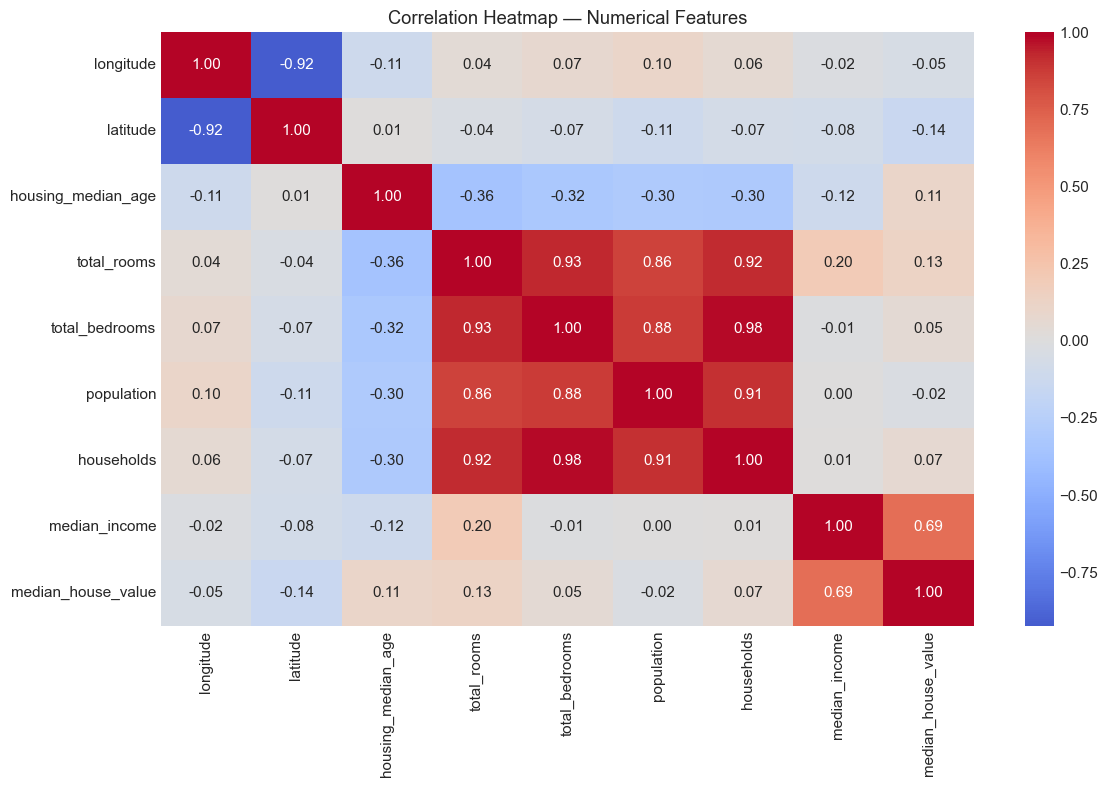

In [7]:
# ============================================================
# REGRESSION — A2: CORRELATION HEATMAP
# ============================================================

numeric_df = df_raw.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()

Selected features for scatter plots:
['median_income', 'latitude']


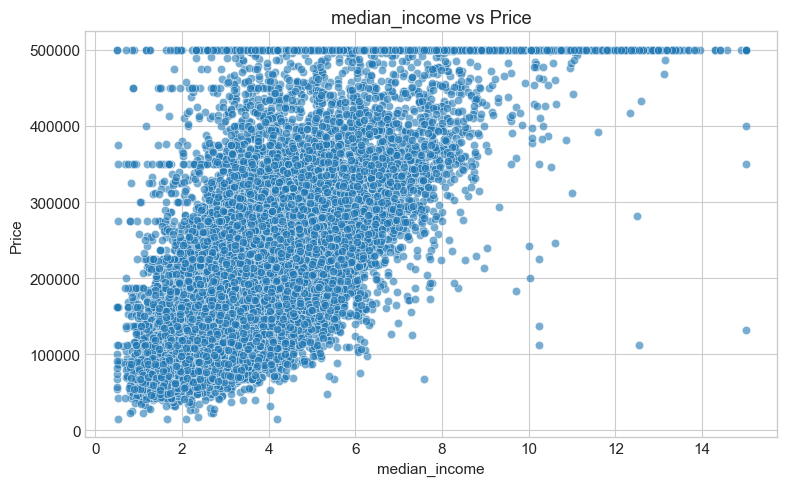

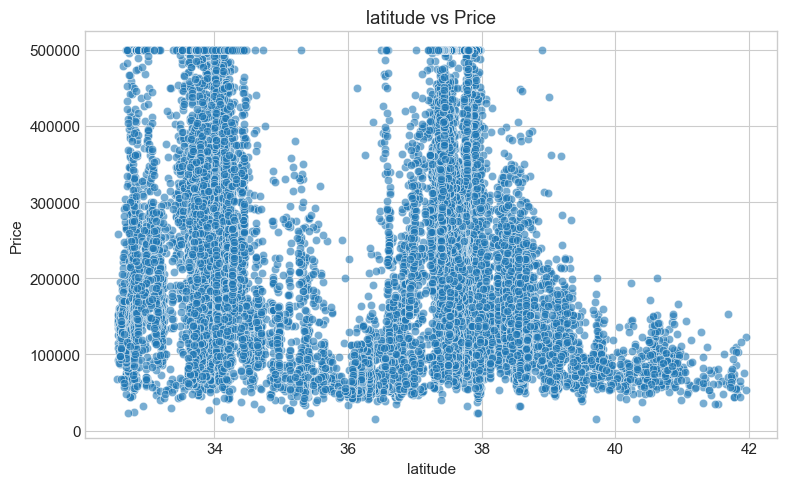

In [8]:
# ============================================================
# REGRESSION — A2: TWO FEATURE VS TARGET SCATTER PLOTS
# ============================================================

numeric_features = [
    col for col in numeric_df.columns
    if col != target_col
]

correlations = (
    numeric_df[numeric_features]
    .corrwith(numeric_df[target_col])
    .abs()
    .sort_values(ascending=False)
)

top_two_features = correlations.head(2).index.tolist()

print("Selected features for scatter plots:")
print(top_two_features)

for feature in top_two_features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df_raw,
        x=feature,
        y=target_col,
        alpha=0.6
    )

    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price")

    plt.tight_layout()
    plt.show()

In [9]:
# ============================================================
# REGRESSION — A3: EDA OBSERVATIONS
# ============================================================

print("""
EDA Observations:

1. The target variable (price) shows the distribution visible in
   the target histogram, with variation across the observations.

2. The feature distribution plots show that different numerical
   and categorical features have different ranges and distributions.

3. The correlation heatmap indicates that some numerical features
   have stronger relationships with the target than others.

4. The feature-vs-target scatter plots show the relationship between
   the selected predictors and house price. Features with stronger
   correlation show a clearer trend with the target.

5. Some variables may exhibit skewness or concentration in particular
   ranges, which should be considered during preprocessing and
   model development.
""")


EDA Observations:

1. The target variable (price) shows the distribution visible in
   the target histogram, with variation across the observations.

2. The feature distribution plots show that different numerical
   and categorical features have different ranges and distributions.

3. The correlation heatmap indicates that some numerical features
   have stronger relationships with the target than others.

4. The feature-vs-target scatter plots show the relationship between
   the selected predictors and house price. Features with stronger
   correlation show a clearer trend with the target.

5. Some variables may exhibit skewness or concentration in particular
   ranges, which should be considered during preprocessing and
   model development.



A3-Insight Commentary 

## Section B - Preprocessing & Feature Engineering

### B1 & B3: Feature Engineering & Missing Value Handling
We create 3 key ratio features to capture structural density per household:
1. `rooms_per_household` = `total_rooms` / `households`
2. `bedrooms_per_room` = `total_bedrooms` / `total_rooms`
3. `population_per_household` = `population` / `households`


In [10]:
df_clean = df_raw.copy()

# B3: Feature Engineering
df_clean['rooms_per_household'] = df_clean['total_rooms'] / df_clean['households']
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population'] / df_clean['households']

# Separate Features (X) & Target (y)
X = df_clean.drop(columns=['median_house_value'])
y = df_clean['median_house_value']

cat_cols = ['ocean_proximity']
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Engineered Dataset shape: {X.shape}")
print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)


Engineered Dataset shape: (20640, 12)
Numerical Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical Features: ['ocean_proximity']


### B2: Train/Test Split (80:20) & Preprocessing Pipeline
We use `ColumnTransformer` to fit `SimpleImputer` and `StandardScaler` strictly on `X_train` to prevent data leakage. Categorical features are encoded via `OneHotEncoder(drop='first')`.


In [11]:
# 80:20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Numeric Preprocessing Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Full Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

# Fit strictly on X_train
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Extract Feature Names
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(encoded_cat_names)

print(f"Preprocessed X_train Shape: {X_train_prep.shape}")
print(f"Preprocessed X_test Shape: {X_test_prep.shape}")
print("Feature Names count:", len(feature_names))


Preprocessed X_train Shape: (16512, 15)
Preprocessed X_test Shape: (4128, 15)
Feature Names count: 15


## Section C - Regression Track: Training & Evaluation (10 Algorithms)

We evaluate all 10 mandated algorithms on the exact same test split using $R^2$, RMSE, and MAE.


In [12]:
# ============================================================
# SECTION C: REGRESSION MODEL TRAINING & EVALUATION
# All 10 mandated regression algorithms
# ============================================================

results_reg = []
trained_models = {}
predictions_reg = {}

def evaluate_regressor(name, model, X_tr, X_te, y_tr, y_te):
    print(f"Training: {name}")

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)

    trained_models[name] = model
    predictions_reg[name] = y_pred

    result = {
        "Algorithm": name,
        "R2_Score": r2,
        "RMSE": rmse,
        "MAE": mae
    }

    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : ${rmse:,.2f}")
    print(f"  MAE  : ${mae:,.2f}")
    print("  Completed.\n")

    return result


# ------------------------------------------------------------
# 1. Linear Regression (Baseline)
# ------------------------------------------------------------
res = evaluate_regressor(
    "1. Linear Regression",
    LinearRegression(),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 2. Ridge Regression
# ------------------------------------------------------------
res = evaluate_regressor(
    "2. Ridge Regression (alpha=1.0)",
    Ridge(alpha=1.0, random_state=42),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 3. Lasso Regression
# ------------------------------------------------------------
res = evaluate_regressor(
    "3. Lasso Regression (alpha=100.0)",
    Lasso(alpha=100.0, random_state=42, max_iter=5000),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 4. ElasticNet Regression
# ------------------------------------------------------------
res = evaluate_regressor(
    "4. ElasticNet Regression",
    ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        random_state=42,
        max_iter=5000
    ),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 5. Polynomial Regression (Degree 2)
# ------------------------------------------------------------
print("Training: 5. Polynomial Regression (deg=2)")

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_tr_poly = poly.fit_transform(X_train_prep)
X_te_poly = poly.transform(X_test_prep)

model_poly = LinearRegression()
model_poly.fit(X_tr_poly, y_train)

y_pred_poly = model_poly.predict(X_te_poly)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

trained_models["5. Polynomial Regression (deg=2)"] = model_poly
predictions_reg["5. Polynomial Regression (deg=2)"] = y_pred_poly

results_reg.append({
    "Algorithm": "5. Polynomial Regression (deg=2)",
    "R2_Score": r2_poly,
    "RMSE": rmse_poly,
    "MAE": mae_poly
})

print(f"  R²   : {r2_poly:.4f}")
print(f"  RMSE : ${rmse_poly:,.2f}")
print(f"  MAE  : ${mae_poly:,.2f}")
print("  Completed.\n")


# ------------------------------------------------------------
# 6. Decision Tree Regressor
# ------------------------------------------------------------
res = evaluate_regressor(
    "6. Decision Tree Regressor (max_depth=8)",
    DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 7. Random Forest Regressor
# ------------------------------------------------------------
res = evaluate_regressor(
    "7. Random Forest Regressor",
    RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 8. Gradient Boosting Regressor
# ------------------------------------------------------------
res = evaluate_regressor(
    "8. Gradient Boosting Regressor",
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 9. Support Vector Regressor
# Faster RBF configuration for the 20,640-row dataset
# ------------------------------------------------------------
res = evaluate_regressor(
    "9. Support Vector Regressor (SVR)",
    SVR(
        kernel="rbf",
        C=100,
        max_iter=1000
    ),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ------------------------------------------------------------
# 10. K-Nearest Neighbors Regressor
# ------------------------------------------------------------
res = evaluate_regressor(
    "10. K-Nearest Neighbors Regressor (k=5)",
    KNeighborsRegressor(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    ),
    X_train_prep, X_test_prep, y_train, y_test
)
results_reg.append(res)


# ============================================================
# CONSOLIDATED RESULTS TABLE
# ============================================================

df_results_reg = (
    pd.DataFrame(results_reg)
    .sort_values(by="R2_Score", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("CONSOLIDATED REGRESSION BENCHMARK SUMMARY TABLE")
print("=" * 80)

display(
    df_results_reg.style.format({
        "R2_Score": "{:.4f}",
        "RMSE": "${:,.2f}",
        "MAE": "${:,.2f}"
    })
)

print("\nBest model based on R²:")
print(df_results_reg.iloc[0]["Algorithm"])

Training: 1. Linear Regression
  R²   : 0.6353
  RMSE : $69,127.04
  MAE  : $49,645.49
  Completed.

Training: 2. Ridge Regression (alpha=1.0)
  R²   : 0.6352
  RMSE : $69,136.26
  MAE  : $49,653.25
  Completed.

Training: 3. Lasso Regression (alpha=100.0)
  R²   : 0.6348
  RMSE : $69,179.21
  MAE  : $49,648.56
  Completed.

Training: 4. ElasticNet Regression
  R²   : 0.6287
  RMSE : $69,757.85
  MAE  : $50,091.85
  Completed.

Training: 5. Polynomial Regression (deg=2)
  R²   : 0.6209
  RMSE : $70,480.08
  MAE  : $44,709.93
  Completed.

Training: 6. Decision Tree Regressor (max_depth=8)
  R²   : 0.7073
  RMSE : $61,928.77
  MAE  : $41,936.01
  Completed.

Training: 7. Random Forest Regressor
  R²   : 0.7963
  RMSE : $51,668.88
  MAE  : $33,800.13
  Completed.

Training: 8. Gradient Boosting Regressor
  R²   : 0.7807
  RMSE : $53,612.12
  MAE  : $36,523.02
  Completed.

Training: 9. Support Vector Regressor (SVR)
  R²   : -0.0871
  RMSE : $119,355.55
  MAE  : $101,782.44
  Completed.


,Algorithm,R2_Score,RMSE,MAE
0,7. Random Forest Regressor,0.7963,"$51,668.88","$33,800.13"
1,8. Gradient Boosting Regressor,0.7807,"$53,612.12","$36,523.02"
2,10. K-Nearest Neighbors Regressor (k=5),0.7120,"$61,429.77","$40,669.99"
3,6. Decision Tree Regressor (max_depth=8),0.7073,"$61,928.77","$41,936.01"
4,1. Linear Regression,0.6353,"$69,127.04","$49,645.49"
5,2. Ridge Regression (alpha=1.0),0.6352,"$69,136.26","$49,653.25"
6,3. Lasso Regression (alpha=100.0),0.6348,"$69,179.21","$49,648.56"
7,4. ElasticNet Regression,0.6287,"$69,757.85","$50,091.85"
8,5. Polynomial Regression (deg=2),0.6209,"$70,480.08","$44,709.93"
9,9. Support Vector Regressor (SVR),-0.0871,"$119,355.55","$101,782.44"



Best model based on R²:
7. Random Forest Regressor


### C2 — 5-Fold Cross-Validation

The two strongest ensemble models from the initial regression comparison, Random Forest and Gradient Boosting, are evaluated using 5-fold cross-validation on the training data. The mean and standard deviation of the R² scores are reported to assess model stability and generalization performance.

### C3 — Hyperparameter Tuning

To improve the performance of the two strongest ensemble models, Random Forest and Gradient Boosting are independently tuned using GridSearchCV with 5-fold cross-validation.

For each model, a compact hyperparameter grid is searched using R² as the scoring metric. The best hyperparameters and corresponding cross-validation R² score are reported. Each tuned model is then evaluated on the same held-out test set used for the initial model comparison.

Finally, the baseline and tuned R² scores are compared for both models, and the improvement in R² is reported. The tuned model with the highest test-set R² is selected as the final best model for subsequent diagnostic analysis.


In [13]:
# ============================================================
# SECTION C2 & C3
# 5-Fold Cross-Validation + Hyperparameter Tuning
# ============================================================

print("=" * 80)
print("C2: 5-FOLD CROSS-VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Top 2 ensemble models
# ------------------------------------------------------------

rf_top = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

gbr_top = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 5-fold CV for Random Forest
print("Running 5-fold CV for Random Forest...")

rf_cv = cross_val_score(
    rf_top,
    X_train_prep,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# 5-fold CV for Gradient Boosting
print("Running 5-fold CV for Gradient Boosting...")

gbr_cv = cross_val_score(
    gbr_top,
    X_train_prep,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("\n--- 5-Fold Cross-Validation Results ---")
print(
    f"Random Forest R²: "
    f"{rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})"
)

print(
    f"Gradient Boosting R²: "
    f"{gbr_cv.mean():.4f} (+/- {gbr_cv.std():.4f})"
)

# ============================================================
# C3: HYPERPARAMETER TUNING — TOP 2 MODELS
# Random Forest + Gradient Boosting
# ============================================================

print("\n" + "=" * 80)
print("C3: HYPERPARAMETER TUNING — RANDOM FOREST + GRADIENT BOOSTING")
print("=" * 80)


# ============================================================
# 1. RANDOM FOREST — GRIDSEARCHCV
# ============================================================

print("\n" + "-" * 80)
print("Random Forest Hyperparameter Tuning")
print("-" * 80)

rf_param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 12, None],
    "min_samples_split": [2, 5]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    refit=True
)

print("Starting Random Forest GridSearchCV...")

rf_grid_search.fit(
    X_train_prep,
    y_train
)

best_rf = rf_grid_search.best_estimator_

print("\n--- Random Forest GridSearchCV Results ---")
print("Best Hyperparameters:")
print(rf_grid_search.best_params_)

print(
    f"\nBest 5-Fold CV R²: "
    f"{rf_grid_search.best_score_:.4f}"
)


# ============================================================
# RANDOM FOREST — TEST SET EVALUATION
# ============================================================

y_pred_rf_tuned = best_rf.predict(X_test_prep)

rf_r2_tuned = r2_score(
    y_test,
    y_pred_rf_tuned
)

rf_rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_tuned
    )
)

rf_mae_tuned = mean_absolute_error(
    y_test,
    y_pred_rf_tuned
)

print("\n--- Tuned Random Forest Test Performance ---")

print(
    f"Tuned RF Test R²   : {rf_r2_tuned:.4f}"
)

print(
    f"Tuned RF Test RMSE : ${rf_rmse_tuned:,.2f}"
)

print(
    f"Tuned RF Test MAE  : ${rf_mae_tuned:,.2f}"
)


# ============================================================
# 2. GRADIENT BOOSTING — GRIDSEARCHCV
# ============================================================

print("\n" + "-" * 80)
print("Gradient Boosting Hyperparameter Tuning")
print("-" * 80)

gbr_param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [5, 6]
}

gbr_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gbr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    refit=True
)

print("Starting Gradient Boosting GridSearchCV...")

gbr_grid_search.fit(
    X_train_prep,
    y_train
)

best_gbr = gbr_grid_search.best_estimator_

print("\n--- Gradient Boosting GridSearchCV Results ---")
print("Best Hyperparameters:")
print(gbr_grid_search.best_params_)

print(
    f"\nBest 5-Fold CV R²: "
    f"{gbr_grid_search.best_score_:.4f}"
)


# ============================================================
# GRADIENT BOOSTING — TEST SET EVALUATION
# ============================================================

y_pred_gbr_tuned = best_gbr.predict(X_test_prep)

gbr_r2_tuned = r2_score(
    y_test,
    y_pred_gbr_tuned
)

gbr_rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gbr_tuned
    )
)

gbr_mae_tuned = mean_absolute_error(
    y_test,
    y_pred_gbr_tuned
)

print("\n--- Tuned Gradient Boosting Test Performance ---")

print(
    f"Tuned GBR Test R²   : {gbr_r2_tuned:.4f}"
)

print(
    f"Tuned GBR Test RMSE : ${gbr_rmse_tuned:,.2f}"
)

print(
    f"Tuned GBR Test MAE  : ${gbr_mae_tuned:,.2f}"
)

# ============================================================
# 3. BASELINE VS TUNED COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("BASELINE VS TUNED PERFORMANCE")
print("=" * 80)

# Calculate baseline test-set R² from the original C1 predictions
baseline_rf_r2 = r2_score(
    y_test,
    predictions_reg["7. Random Forest Regressor"]
)

baseline_gbr_r2 = r2_score(
    y_test,
    predictions_reg["8. Gradient Boosting Regressor"]
)

tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],

    "Baseline R²": [
        baseline_rf_r2,
        baseline_gbr_r2
    ],

    "Tuned R²": [
        rf_r2_tuned,
        gbr_r2_tuned
    ]
})

tuning_comparison["R² Improvement"] = (
    tuning_comparison["Tuned R²"]
    - tuning_comparison["Baseline R²"]
)

tuning_comparison["Improvement (%)"] = (
    tuning_comparison["R² Improvement"]
    / tuning_comparison["Baseline R²"]
) * 100

display(
    tuning_comparison.style.format({
        "Baseline R²": "{:.4f}",
        "Tuned R²": "{:.4f}",
        "R² Improvement": "{:.4f}",
        "Improvement (%)": "{:.2f}%"
    })
)

# ============================================================
# 4. SELECT FINAL BEST TUNED MODEL
# ============================================================

if rf_r2_tuned >= gbr_r2_tuned:

    best_model = best_rf
    best_predictions = y_pred_rf_tuned
    best_model_name = "Tuned Random Forest Regressor"

else:

    best_model = best_gbr
    best_predictions = y_pred_gbr_tuned
    best_model_name = "Tuned Gradient Boosting Regressor"


print("\n" + "=" * 80)
print("FINAL BEST MODEL SELECTION")
print("=" * 80)

print(f"Best Model : {best_model_name}")
print(f"Test R²    : {r2_score(y_test, best_predictions):.4f}")
print(f"Test RMSE  : ${np.sqrt(mean_squared_error(y_test, best_predictions)):,.2f}")
print(f"Test MAE   : ${mean_absolute_error(y_test, best_predictions):,.2f}")


C2: 5-FOLD CROSS-VALIDATION
Running 5-fold CV for Random Forest...
Running 5-fold CV for Gradient Boosting...

--- 5-Fold Cross-Validation Results ---
Random Forest R²: 0.8006 (+/- 0.0047)
Gradient Boosting R²: 0.7912 (+/- 0.0057)

C3: HYPERPARAMETER TUNING — RANDOM FOREST + GRADIENT BOOSTING

--------------------------------------------------------------------------------
Random Forest Hyperparameter Tuning
--------------------------------------------------------------------------------
Starting Random Forest GridSearchCV...

--- Random Forest GridSearchCV Results ---
Best Hyperparameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}

Best 5-Fold CV R²: 0.8113

--- Tuned Random Forest Test Performance ---
Tuned RF Test R²   : 0.8121
Tuned RF Test RMSE : $49,616.99
Tuned RF Test MAE  : $31,861.38

--------------------------------------------------------------------------------
Gradient Boosting Hyperparameter Tuning
--------------------------------------------------

,Model,Baseline R²,Tuned R²,R² Improvement,Improvement (%)
0,Random Forest,0.7963,0.8121,0.0159,1.99%
1,Gradient Boosting,0.7807,0.8366,0.0560,7.17%



FINAL BEST MODEL SELECTION
Best Model : Tuned Gradient Boosting Regressor
Test R²    : 0.8366
Test RMSE  : $46,267.30
Test MAE   : $30,189.77


### C4 — Regression Diagnostics and Feature Importance

The best-performing tuned regression model is selected based on test-set R². Diagnostic analysis is performed using residual and predicted-versus-actual plots to assess prediction quality and error patterns.

For the selected tree-based model, feature importance values are extracted from the fitted model and ranked to identify the most influential predictors. The top 15 feature importances are visualized along with the final R², RMSE, MAE, mean residual, and residual standard deviation.


C4: MODEL DIAGNOSTICS
Best Model: Tuned Gradient Boosting Regressor


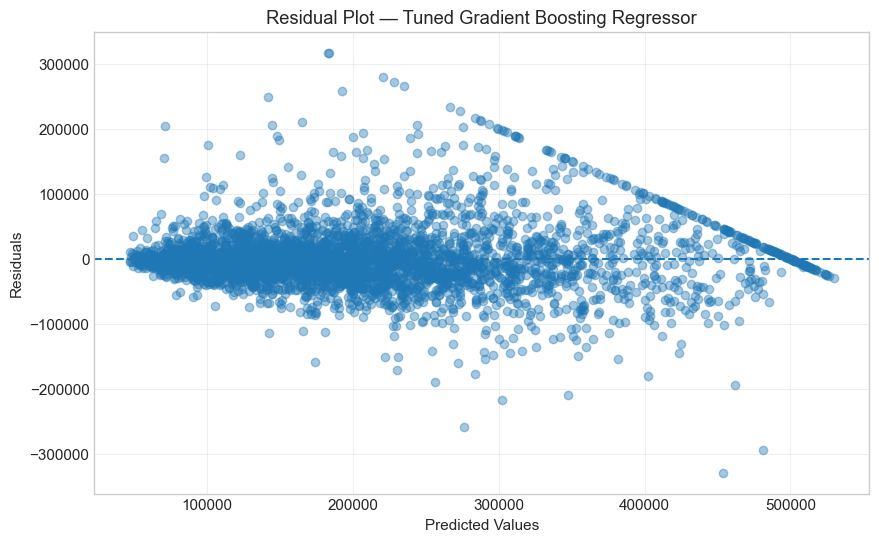

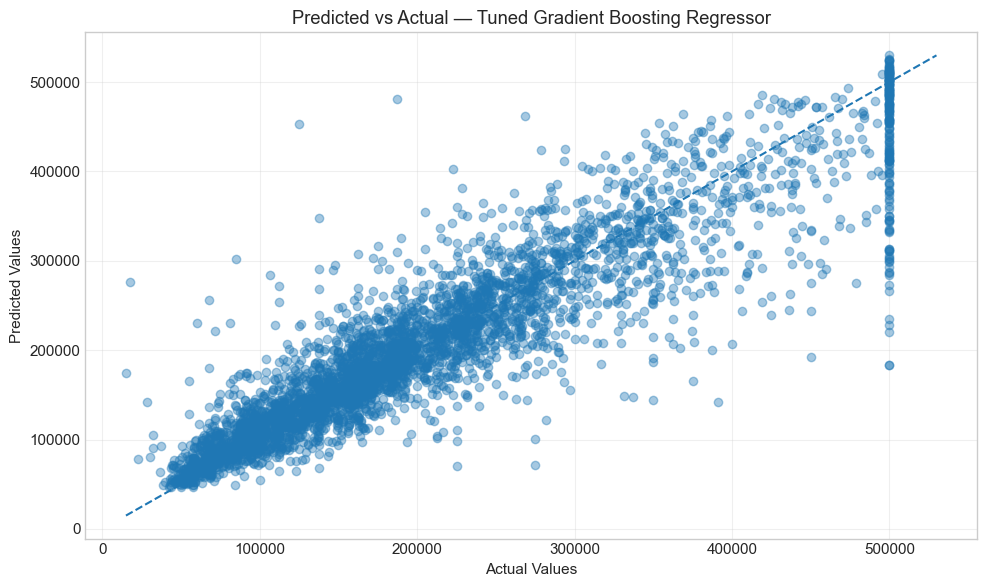


FEATURE IMPORTANCE

Top 15 Most Important Features:


,Feature,Importance
0,num__median_income,0.507484
1,cat__ocean_proximity_INLAND,0.144597
2,num__population_per_household,0.119725
3,num__longitude,0.071942
4,num__latitude,0.062673
5,num__housing_median_age,0.037602
6,num__rooms_per_household,0.015813
7,num__bedrooms_per_room,0.014132
8,num__total_bedrooms,0.005970
9,num__population,0.005687


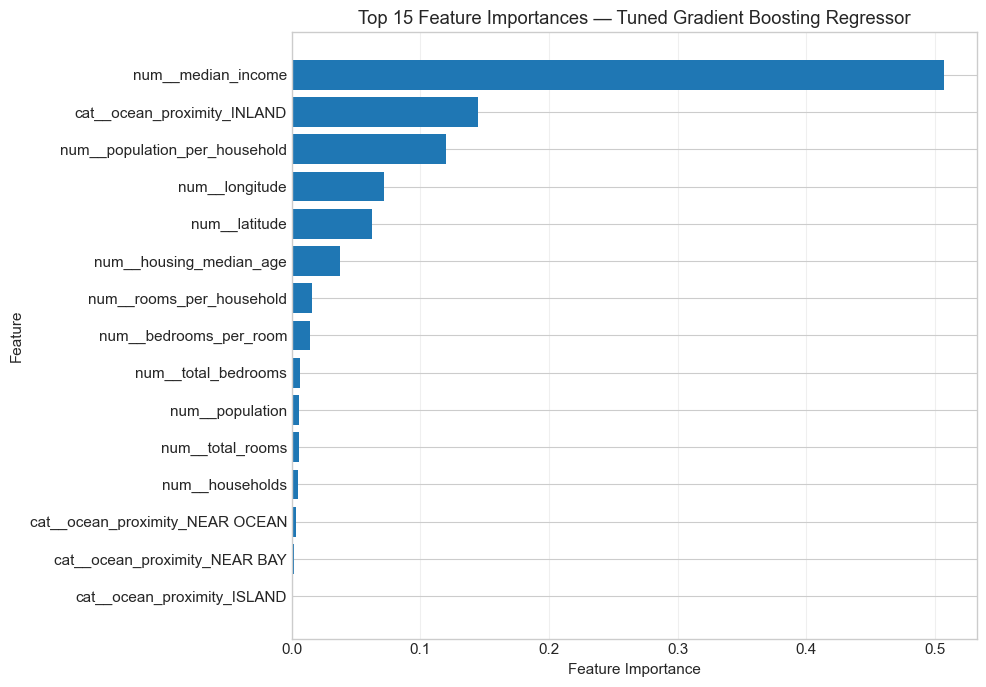


C4 DIAGNOSTIC SUMMARY
Best Model : Tuned Gradient Boosting Regressor
Test R²    : 0.8366
Test RMSE  : $46,267.30
Test MAE   : $30,189.77
Mean Residual : -358.74
Residual Std  : 46,271.51


In [14]:
# ============================================================
# SECTION C4 — MODEL DIAGNOSTICS & FEATURE IMPORTANCE
# ============================================================

print("=" * 80)
print("C4: MODEL DIAGNOSTICS")
print("=" * 80)

print(f"Best Model: {best_model_name}")


# ============================================================
# 1. RESIDUAL CALCULATION
# ============================================================

residuals = y_test - best_predictions


# ============================================================
# 2. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(
    f"Residual Plot — {best_model_name}"
)

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 3. PREDICTED VS ACTUAL PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

# Perfect prediction reference line
min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    f"Predicted vs Actual — {best_model_name}"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

if hasattr(best_model, "feature_importances_"):

    # Get feature importance values
    importances = best_model.feature_importances_

    # Get transformed feature names
    feature_names = preprocessor.get_feature_names_out()

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\nTop 15 Most Important Features:")

    display(
        feature_importance_df.head(15)
    )


    # --------------------------------------------------------
    # Feature Importance Plot
    # --------------------------------------------------------

    plt.figure(figsize=(10, 7))

    top_features = feature_importance_df.head(15)

    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.title(
        f"Top 15 Feature Importances — {best_model_name}"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        f"{best_model_name} does not provide "
        "feature_importances_."
    )


# ============================================================
# 5. DIAGNOSTIC SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("C4 DIAGNOSTIC SUMMARY")
print("=" * 80)

print(f"Best Model : {best_model_name}")

print(
    f"Test R²    : "
    f"{r2_score(y_test, best_predictions):.4f}"
)

print(
    f"Test RMSE  : "
    f"${np.sqrt(mean_squared_error(y_test, best_predictions)):,.2f}"
)

print(
    f"Test MAE   : "
    f"${mean_absolute_error(y_test, best_predictions):,.2f}"
)

print(
    f"Mean Residual : "
    f"{residuals.mean():,.2f}"
)

print(
    f"Residual Std  : "
    f"{residuals.std():,.2f}"
)

In [15]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
   "../models/regression_best_model.pkl"
)

print(
    f"Saved best model ({best_model_name}) "
    "to: ../models/regression_best_model.pkl"
)

Saved best model (Tuned Gradient Boosting Regressor) to: models/regression_best_model.pkl


### Track Conclusion & Review 1 Summary

* **Best Model**: The tuned model with the highest test-set R² is selected as the final regression model.
* **Key Drivers**: Feature importance analysis identifies the most influential predictors for the selected tree-based model.
* **Pipeline Artifact**: The selected best model is serialized for reuse and deployment.
